In [1]:
from pathlib import Path
from typing import Dict

from olbootstrap.plotting._plotting import BootstrapPlotter
from olbootstrap.study._study import UniformCoverageStudy


def load_panels_from_paths(panels_paths: Dict[str, dict], *, loader) -> Dict[str, dict]:
    """Load multiple panels of sweeps from given file paths."""
    panels_sweeps: Dict[str, dict] = {}
    for title, entry in panels_paths.items():
        if "paths" not in entry or "labels" not in entry:
            raise ValueError(f"Panel '{title}' must have 'paths' and 'labels'.")
        sweeps = [loader(str(p)) for p in entry["paths"]]
        panels_sweeps[title] = {"sweeps": sweeps, "labels": list(entry["labels"])}
    return panels_sweeps

/opt/anaconda3/envs/bootstrap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# # entry = next(iter(results.values()))
# # sweep = entry['sweep']

# sweep_path = (
#     Path("..")
#     / "experiments"
#     / "MA_season/sweep_proc-MovingAverage__ma-q17__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p05__n-3500__nseries-150__B-200__trend-0p0001__seaA-0p3__seaP-1000.npz"
# )
# sweep = UniformCoverageStudy.load_sweep(str(sweep_path))

# plotter = BootstrapPlotter(style="science")
# fig, axes = plotter.plot_sweep([sweep], nrows=1, ncols=1, titles=["My sweep"], save_path=None)

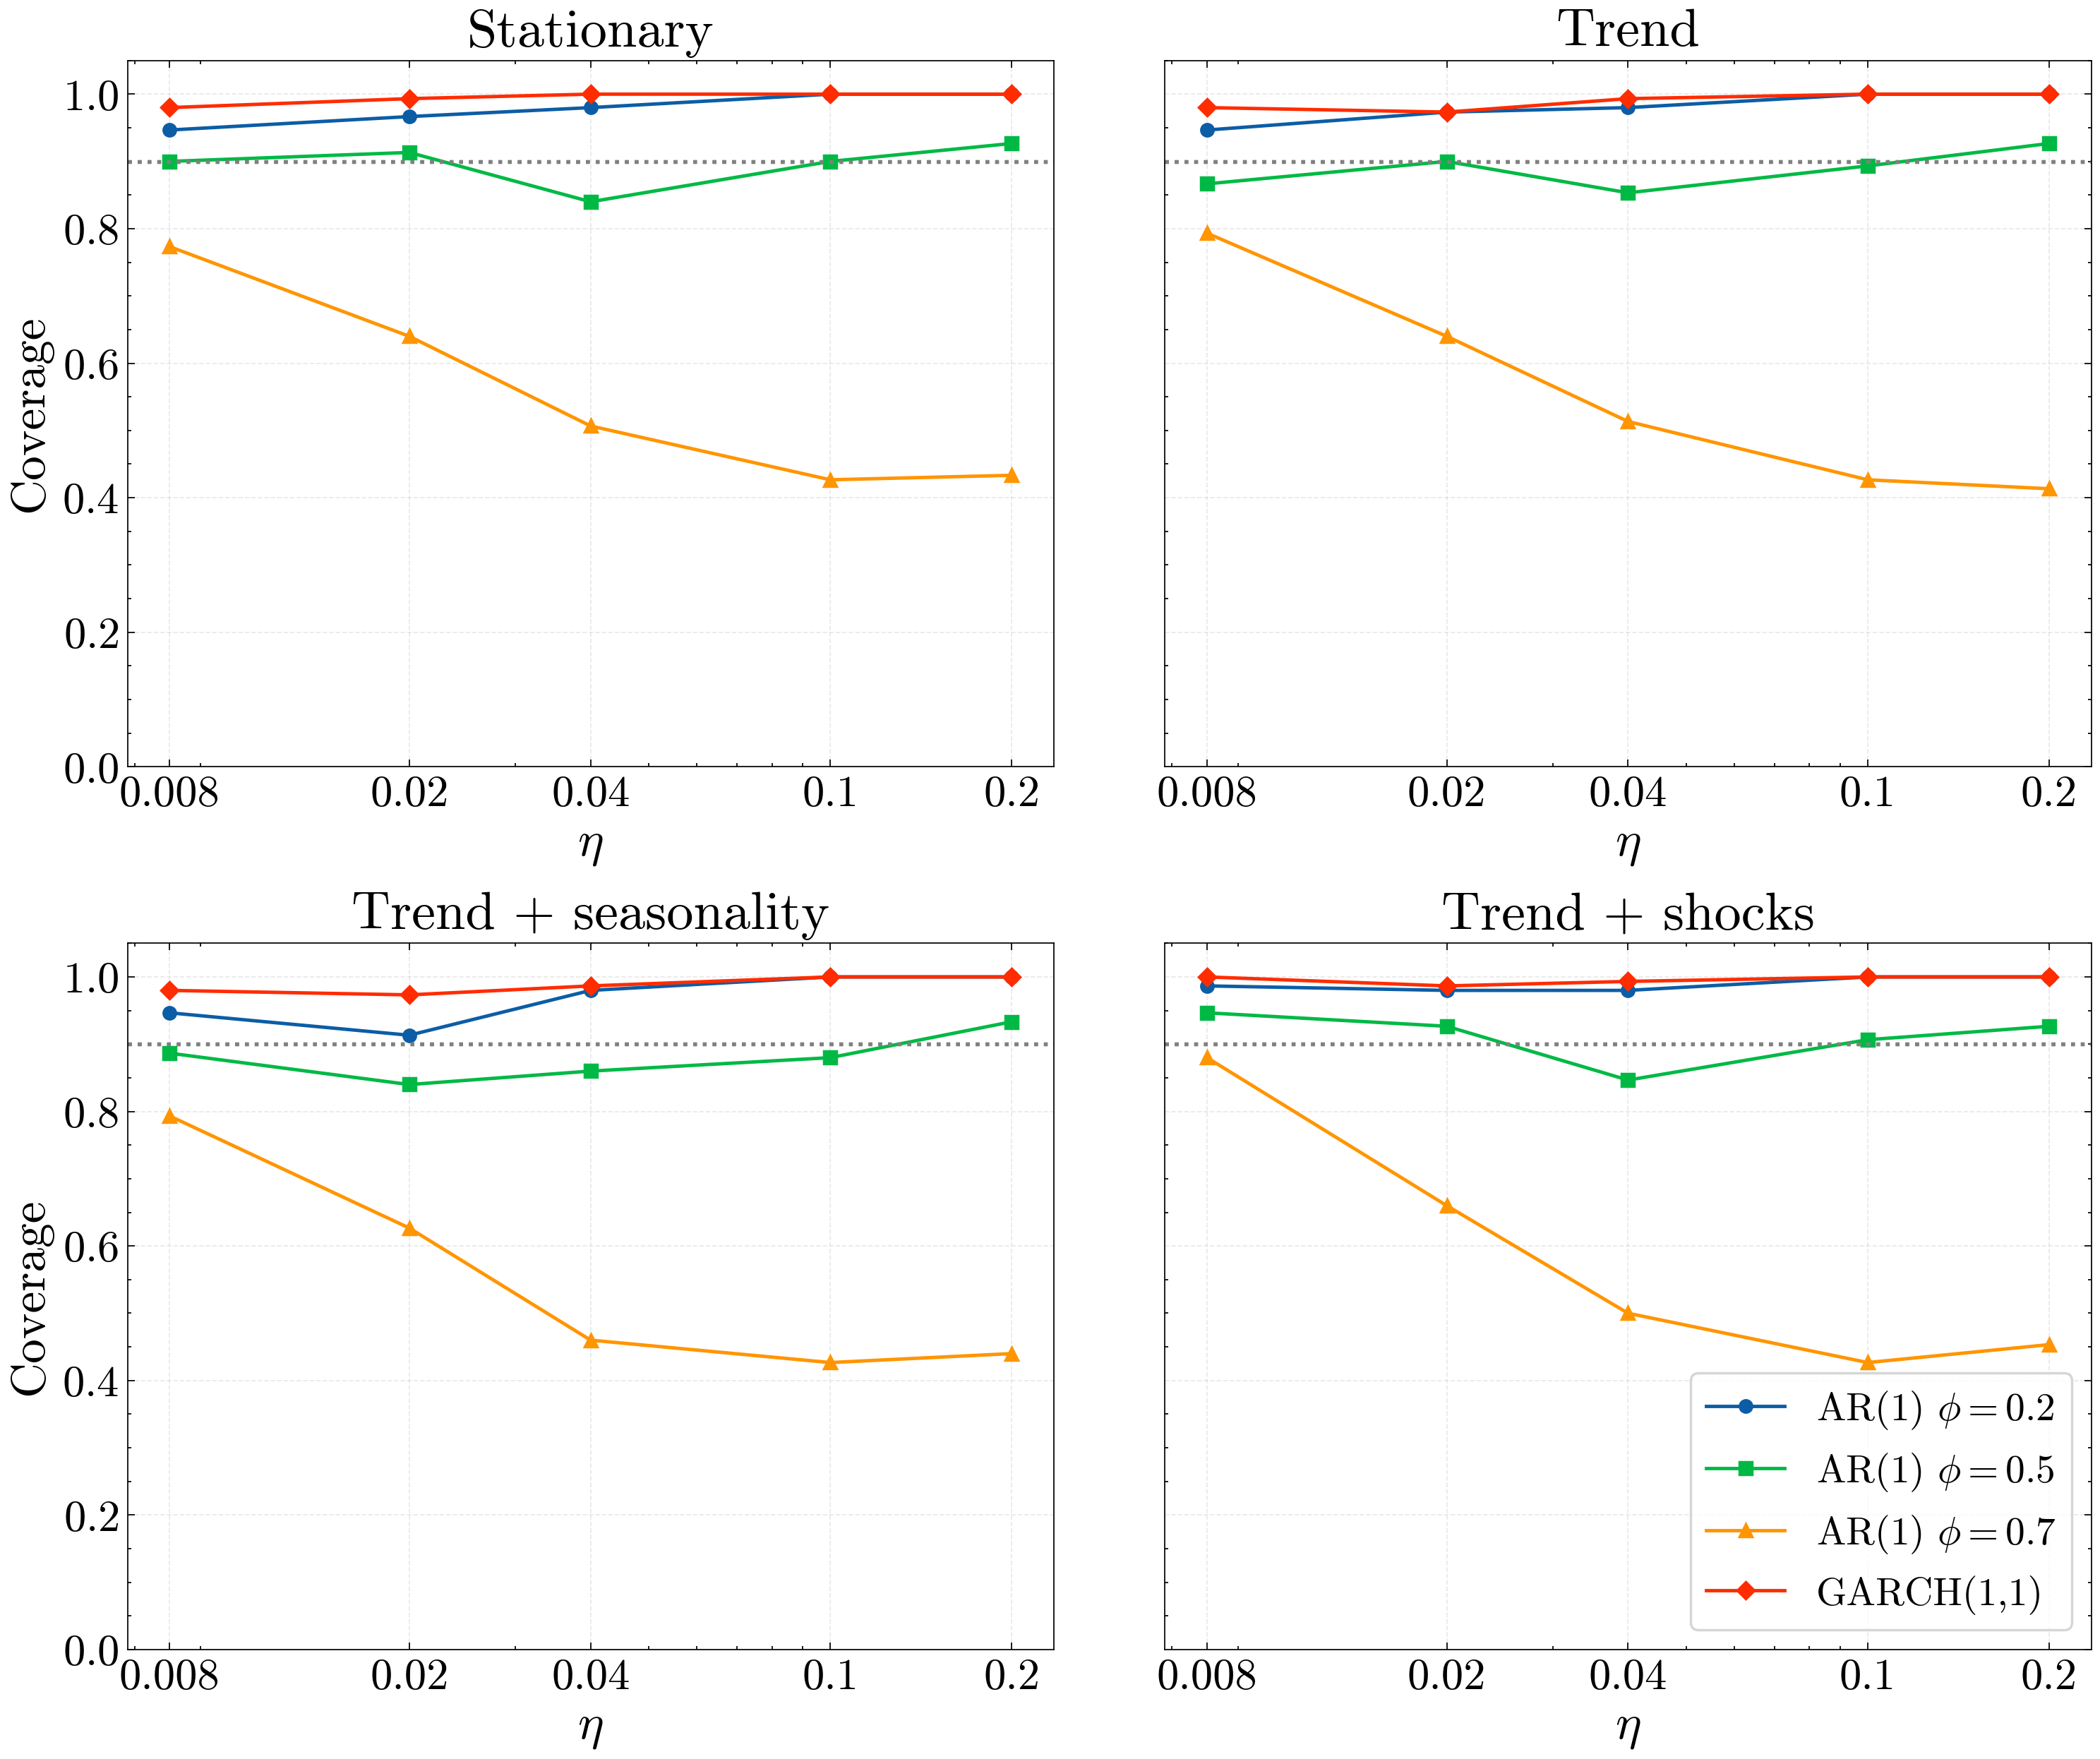

In [3]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "GARCH_base/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend": {
        "paths": [
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_trend/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + seasonality": {
        "paths": [
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "GARCH_season/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_shock/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_ewma_alpha01.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=["Stationary", "Trend", "Trend + seasonality", "Trend + shocks"],
    layout=(2, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=20,
    title_size=22,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

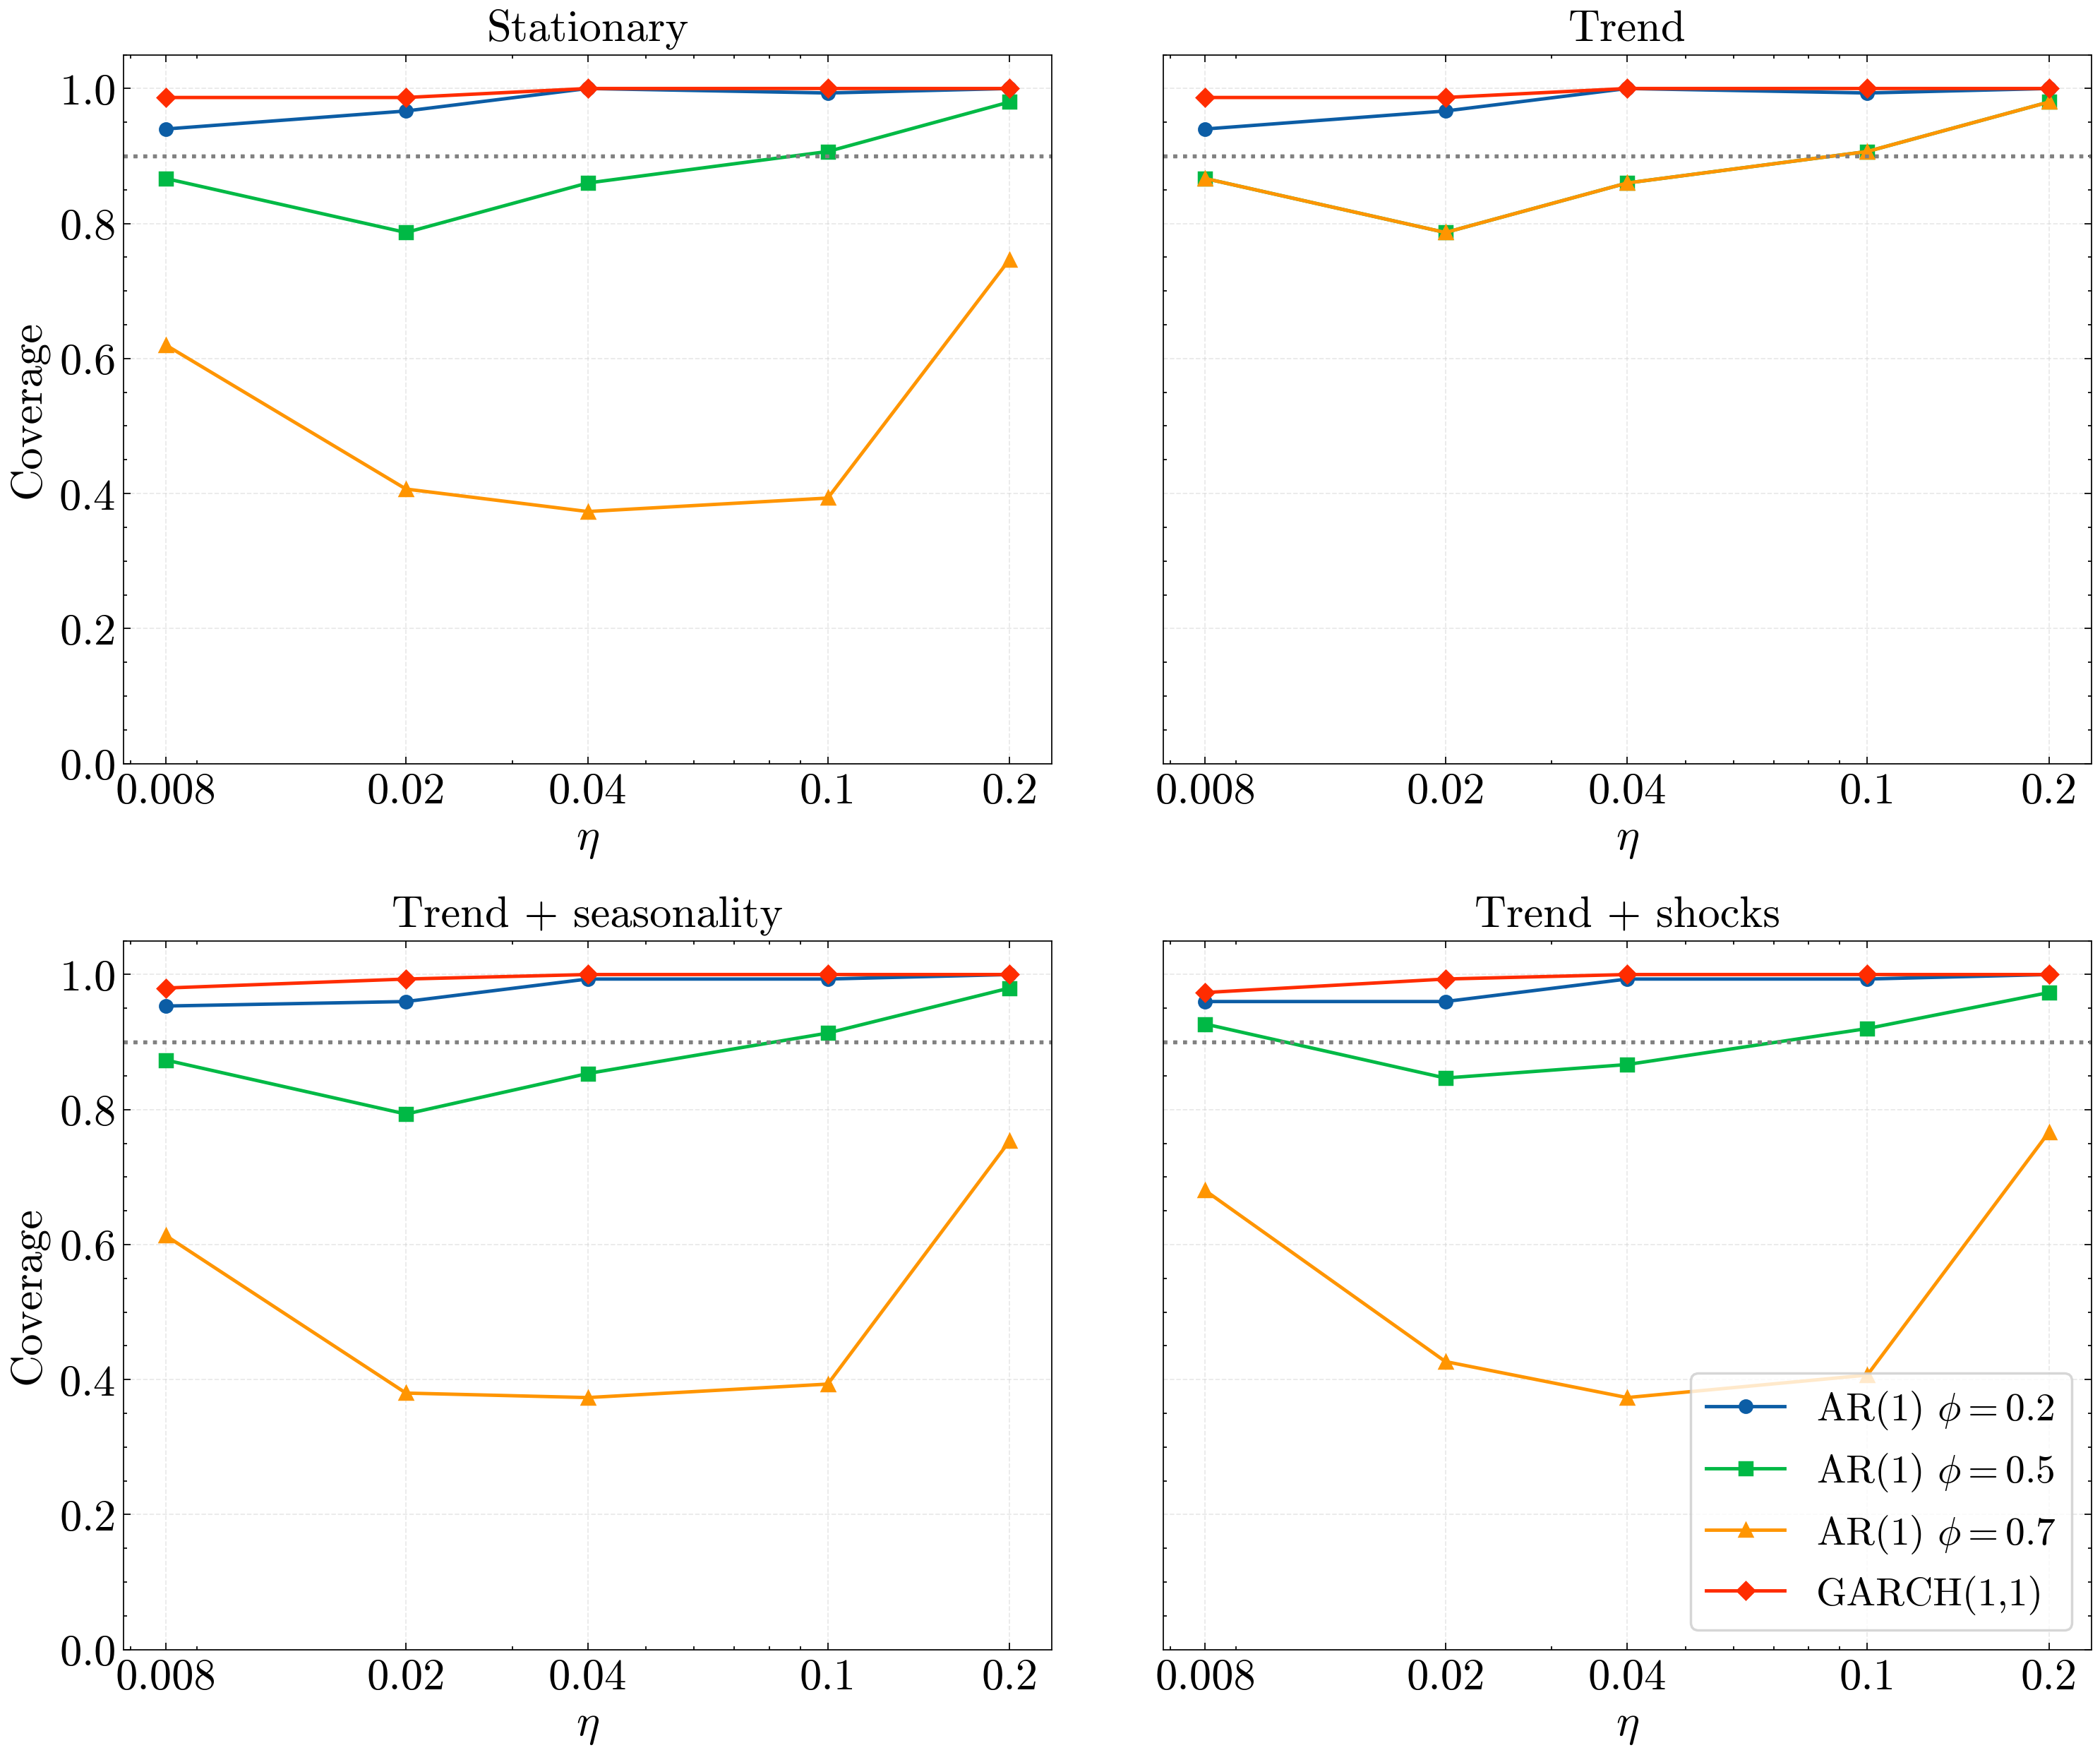

In [4]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "GARCH_base/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend": {
        "paths": [
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_trend/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_trend/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + seasonality": {
        "paths": [
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR1_season/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "GARCH_season/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_shock/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_brown_alpha01.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=["Stationary", "Trend", "Trend + seasonality", "Trend + shocks"],
    layout=(2, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

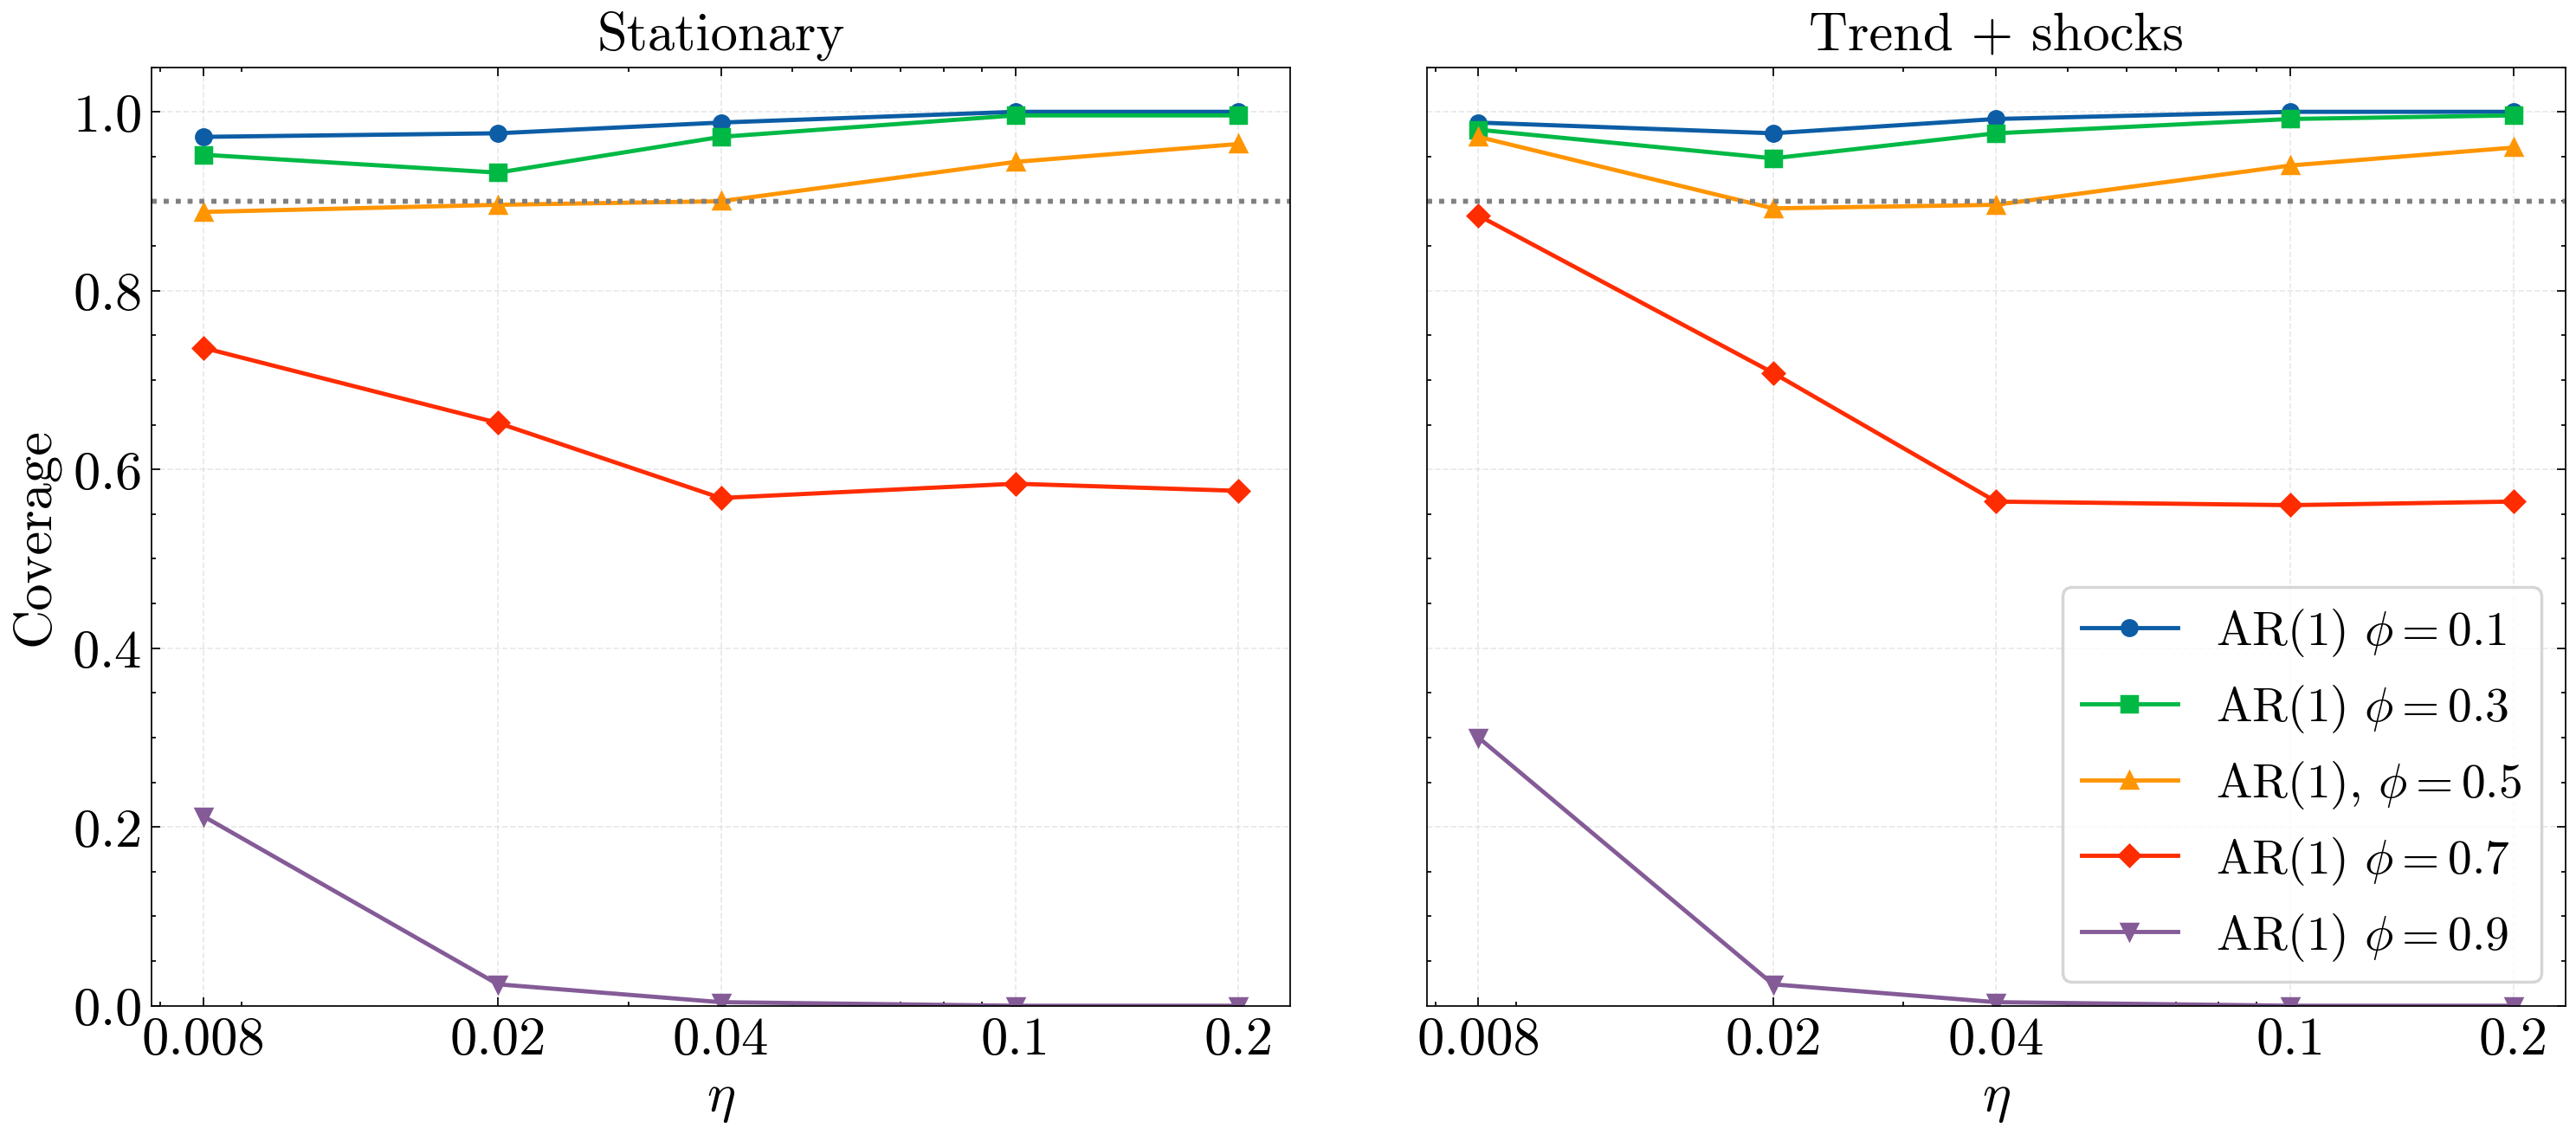

In [5]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR(1) $\phi=0.1$ (base)/sweep_proc-AR1Process__phi-0p1__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200.npz",
            base
            / "AR(1) $\phi=0.3$ (base)/sweep_proc-AR1Process__phi-0p3__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200.npz",
            base
            / "AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200.npz",
            base
            / "AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200.npz",
            base
            / "AR(1) $\phi=0.9$ (base)/sweep_proc-AR1Process__phi-0p9__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.1$",
            "AR(1) $\phi=0.3$",
            r"AR(1), $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"AR(1) $\phi=0.9$",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR(1) $\phi=0.1$ (shocks)/sweep_proc-AR1Process__phi-0p1__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.3$ (shocks)/sweep_proc-AR1Process__phi-0p3__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (shocks)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (shocks)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.9$ (shocks)/sweep_proc-AR1Process__phi-0p9__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-5000__nseries-250__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.1$",
            "AR(1) $\phi=0.3$",
            r"AR(1), $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"AR(1) $\phi=0.9$",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_ar1.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 5), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=["Stationary", "Trend + shocks"],
    layout=(1, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

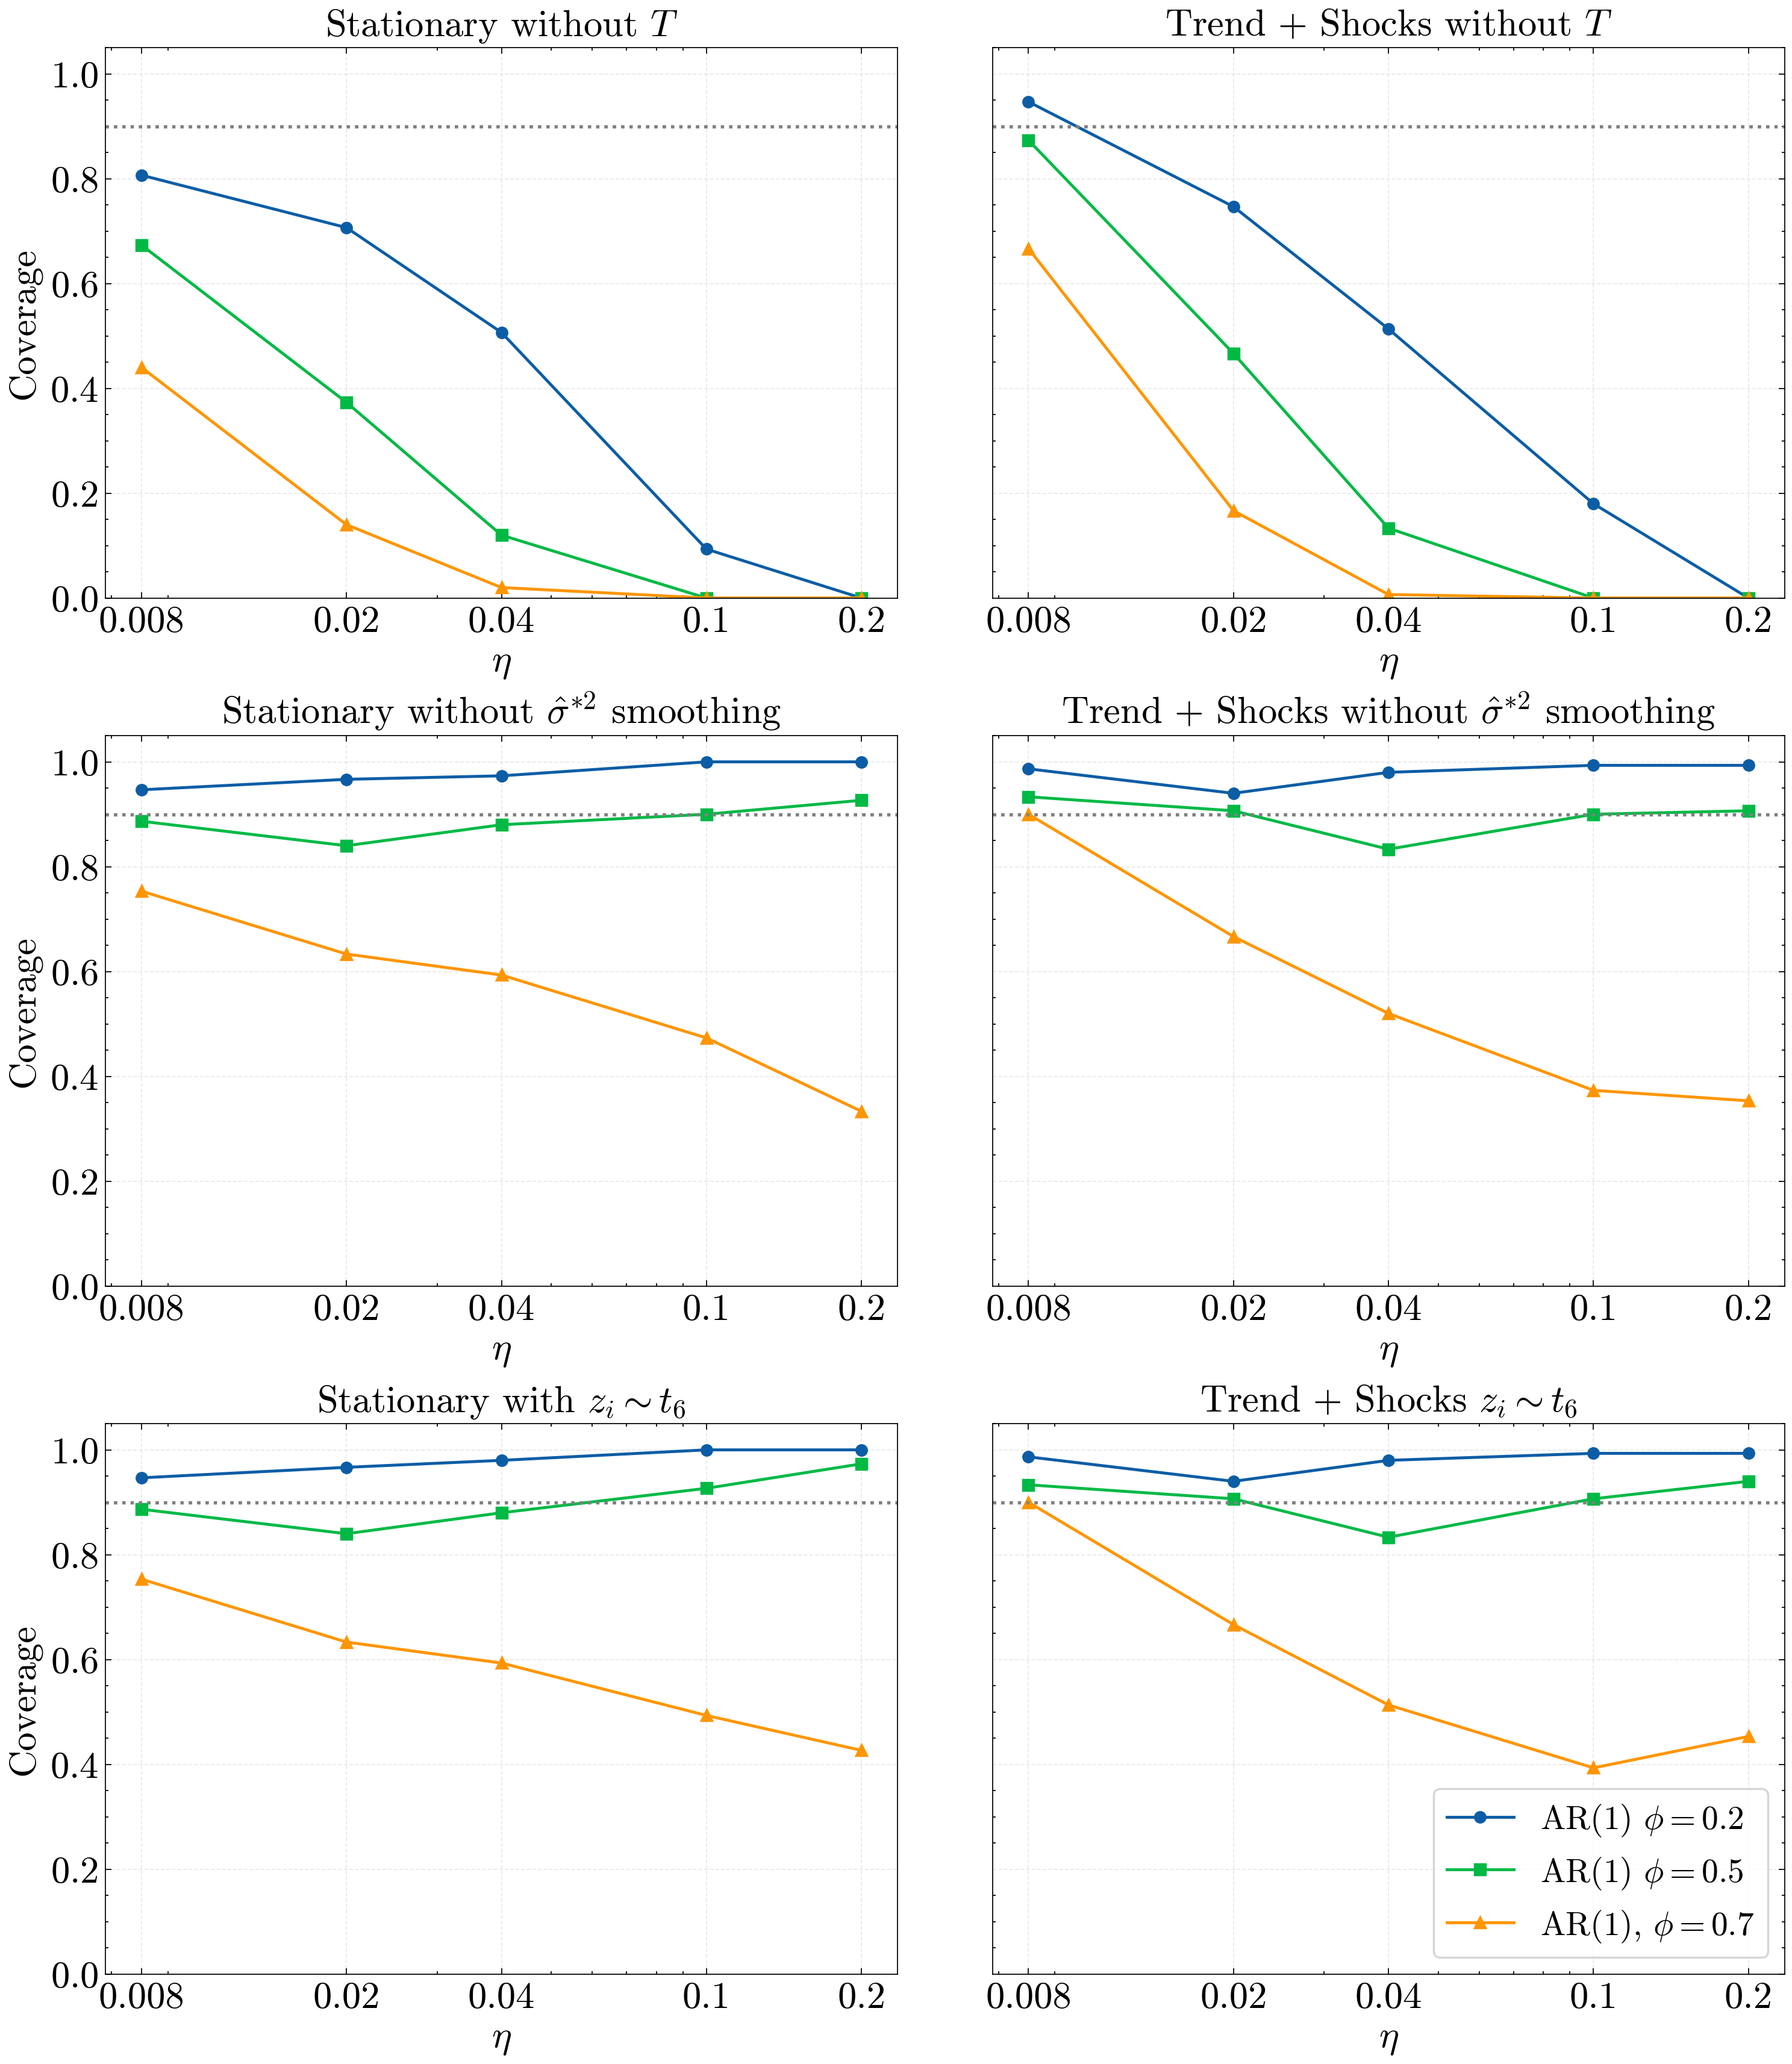

In [6]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary without $T$": {
        "paths": [
            base
            / "AR1_gauss_base/phi_0.2/AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_gauss_base/phi_0.5/AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_gauss_base/phi_0.7/AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
    "Trend + Shocks without $T$": {
        "paths": [
            base
            / "AR1_gauss_shock/phi_0.2/AR(1) $\phi=0.2$ (shock)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_gauss_shock/phi_0.5/AR(1) $\phi=0.5$ (shock)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_gauss_shock/phi_0.7/AR(1) $\phi=0.7$ (shock)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
    "Stationary without $\hat{\sigma}^{*2}$ smoothing": {
        "paths": [
            base
            / "AR1_base_novar/phi_0.2/AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var.npz",
            base
            / "AR1_base_novar/phi_0.5/AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var.npz",
            base
            / "AR1_base_novar/phi_0.7/AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
    "Trend + Shocks without $\hat{\sigma}^{*2}$ smoothing": {
        "paths": [
            base
            / "AR1_shock_novar/phi_0.2/AR(1) $\phi=0.2$ (shock)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__trend-0p001.npz",
            base
            / "AR1_shock_novar/phi_0.5/AR(1) $\phi=0.5$ (shock)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__trend-0p001.npz",
            base
            / "AR1_shock_novar/phi_0.7/AR(1) $\phi=0.7$ (shock)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__trend-0p001.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
    "Stationary with $z_i \sim t_6$": {
        "paths": [
            base
            / "AR1_base_ttails/phi_0.2/AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base_ttails/phi_0.5/AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_base_ttails/phi_0.7/AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
    "Trend + Shocks $z_i \sim t_6$": {
        "paths": [
            base
            / "AR1_shock_ttails/phi_0.2/AR(1) $\phi=0.2$ (shock)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock_ttails/phi_0.5/AR(1) $\phi=0.5$ (shock)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR1_shock_ttails/phi_0.7/AR(1) $\phi=0.7$ (shock)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [r"AR(1) $\phi=0.2$", "AR(1) $\phi=0.5$", r"AR(1), $\phi=0.7$"],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_ar1_gauss_novar_tails.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 14), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=[
        "Stationary without $T$",
        "Trend + Shocks without $T$",
        "Stationary without $\hat{\sigma}^{*2}$ smoothing",
        "Trend + Shocks without $\hat{\sigma}^{*2}$ smoothing",
        "Stationary with $z_i \sim t_6$",
        "Trend + Shocks $z_i \sim t_6$",
    ],
    layout=(3, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

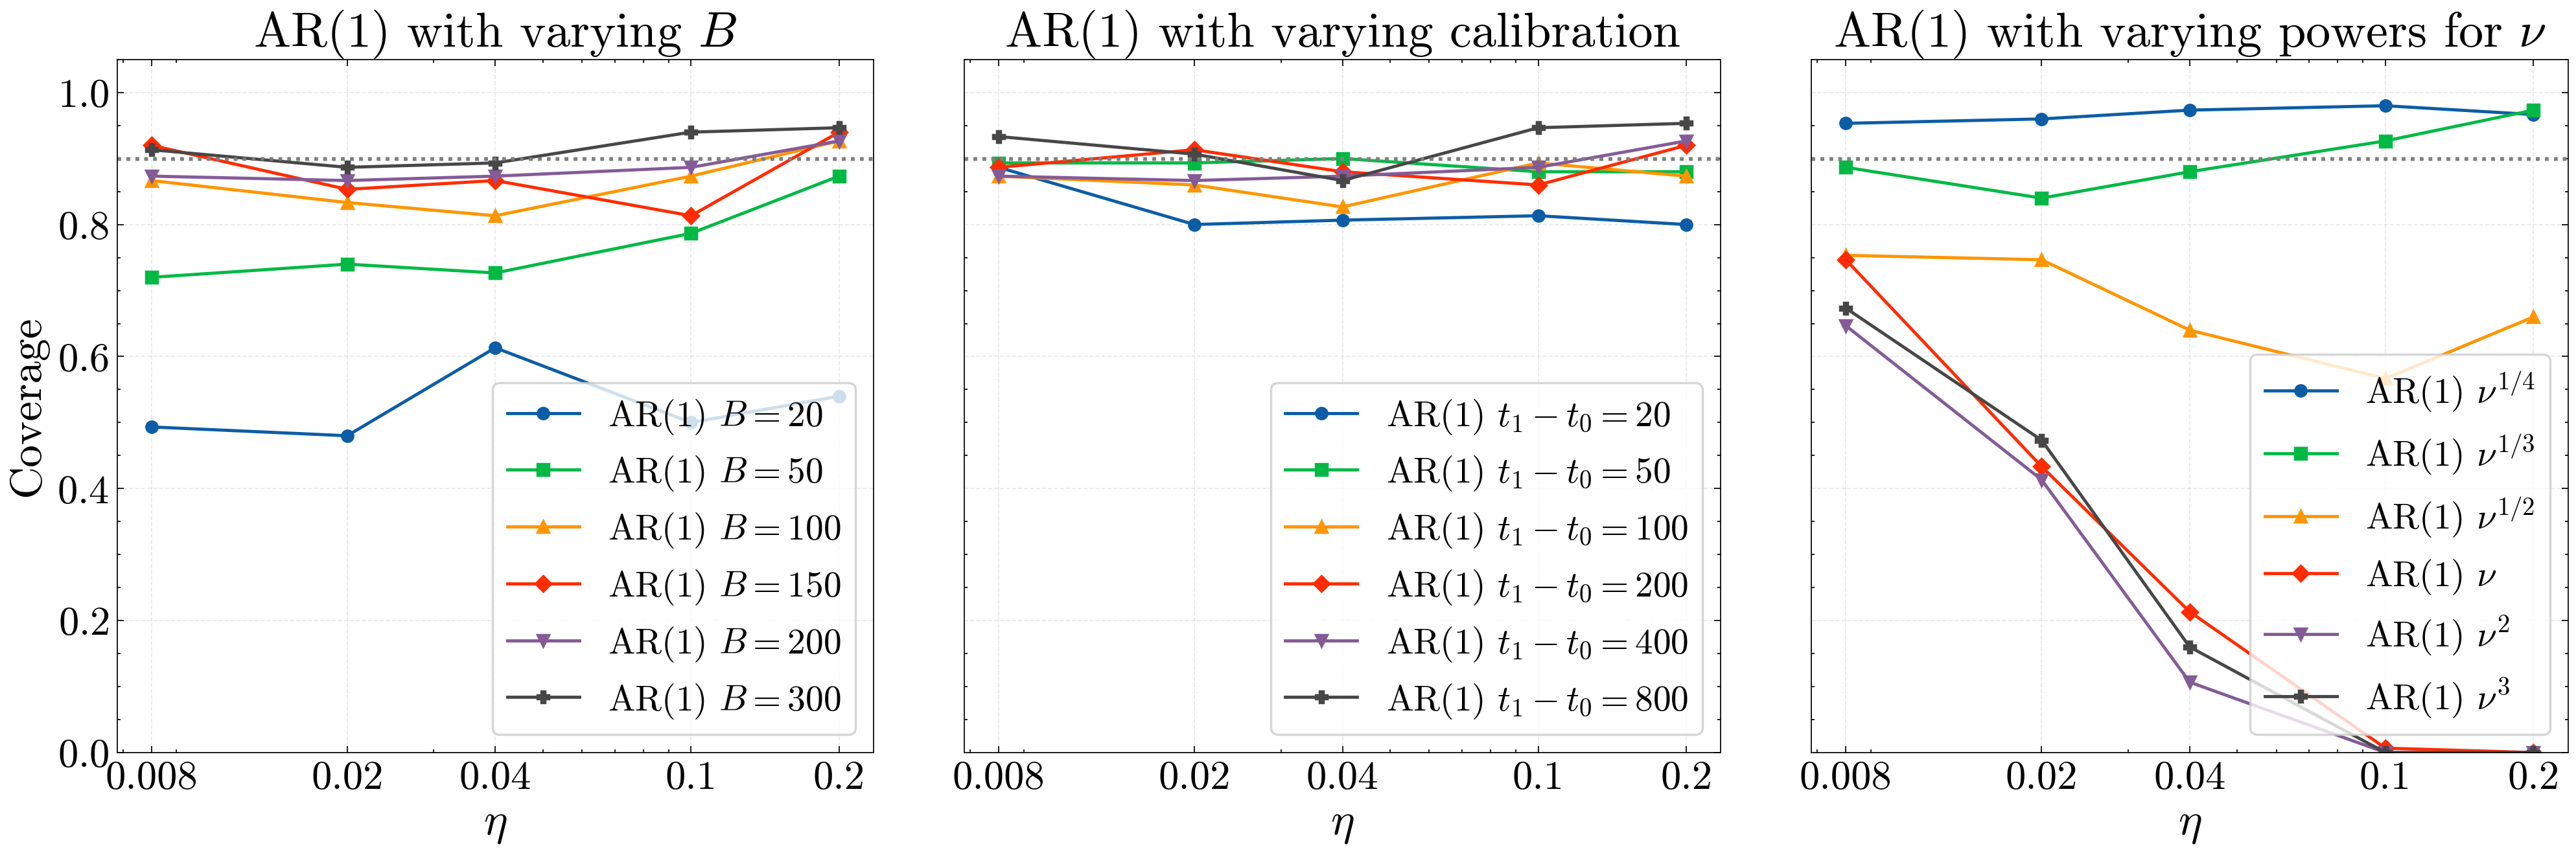

In [7]:
base = Path("..") / "experiments"

panels_paths = {
    "AR(1) with varying $B$": {
        "paths": [
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-20.npz",
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-50.npz",
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-100.npz",
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-150.npz",
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1) B (base)/AR(1) (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-300.npz",
        ],
        "labels": [
            r"AR(1) $B=20$",
            "AR(1) $B=50$",
            r"AR(1) $B=100$",
            r"AR(1) $B=150$",
            r"AR(1) $B=200$",
            r"AR(1) $B=300$",
        ],
    },
    "AR(1) with varying calibration": {
        "paths": [
            base
            / "AR(1)_cal_(base)/vw_20/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-20__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1)_cal_(base)/vw_50/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-50__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1)_cal_(base)/vw_100/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-100__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1)_cal_(base)/vw_200/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-200__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1)_cal_(base)/vw_400/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1)_cal_(base)/vw_800/AR(1) (cal)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-800__alpha-0p1__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [
            r"AR(1) $t_1-t_0=20$",
            "AR(1) $t_1-t_0=50$",
            r"AR(1) $t_1-t_0=100$",
            r"AR(1) $t_1-t_0=200$",
            r"AR(1) $t_1-t_0=400$",
            r"AR(1) $t_1-t_0=800$",
        ],
    },
    r"AR(1) with varying powers for $\nu$": {
        "paths": [
            base
            / "AR1_phi0p5_tp_sweep/tp_0.25/AR(1) $\phi=0.5$ (tp=0.25)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__tp-0p25.npz",
            base
            / "AR1_phi0p5_tp_sweep/tp_0.3333333333333333/AR(1) $\phi=0.5$ (tp=0.333333)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200.npz",
            base
            / "AR1_phi0p5_tp_sweep/tp_0.5/AR(1) $\phi=0.5$ (tp=0.5)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__tp-0p5.npz",
            base
            / "AR1_phi0p5_tp_sweep/tp_1.0/AR(1) $\phi=0.5$ (tp=1)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__tp-1.npz",
            base
            / "AR1_phi0p5_tp_sweep/tp_2.0/AR(1) $\phi=0.5$ (tp=2)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__tp-2.npz",
            base
            / "AR1_phi0p5_tp_sweep/tp_3.0/AR(1) $\phi=0.5$ (tp=3)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__tp-3.npz",
        ],
        "labels": [
            r"AR(1) $\nu^{1/4}$",
            r"AR(1) $\nu^{1/3}$",
            r"AR(1) $\nu^{1/2}$",
            r"AR(1) $\nu$",
            r"AR(1) $\nu^2$",
            r"AR(1) $\nu^3$",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_B_m_nu.pdf"

plotter = BootstrapPlotter(style="science", figsize=(16, 5), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=[
        "AR(1) with varying $B$",
        "AR(1) with varying calibration",
        r"AR(1) with varying powers for $\nu$",
    ],
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=False,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=20,
    title_size=22,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

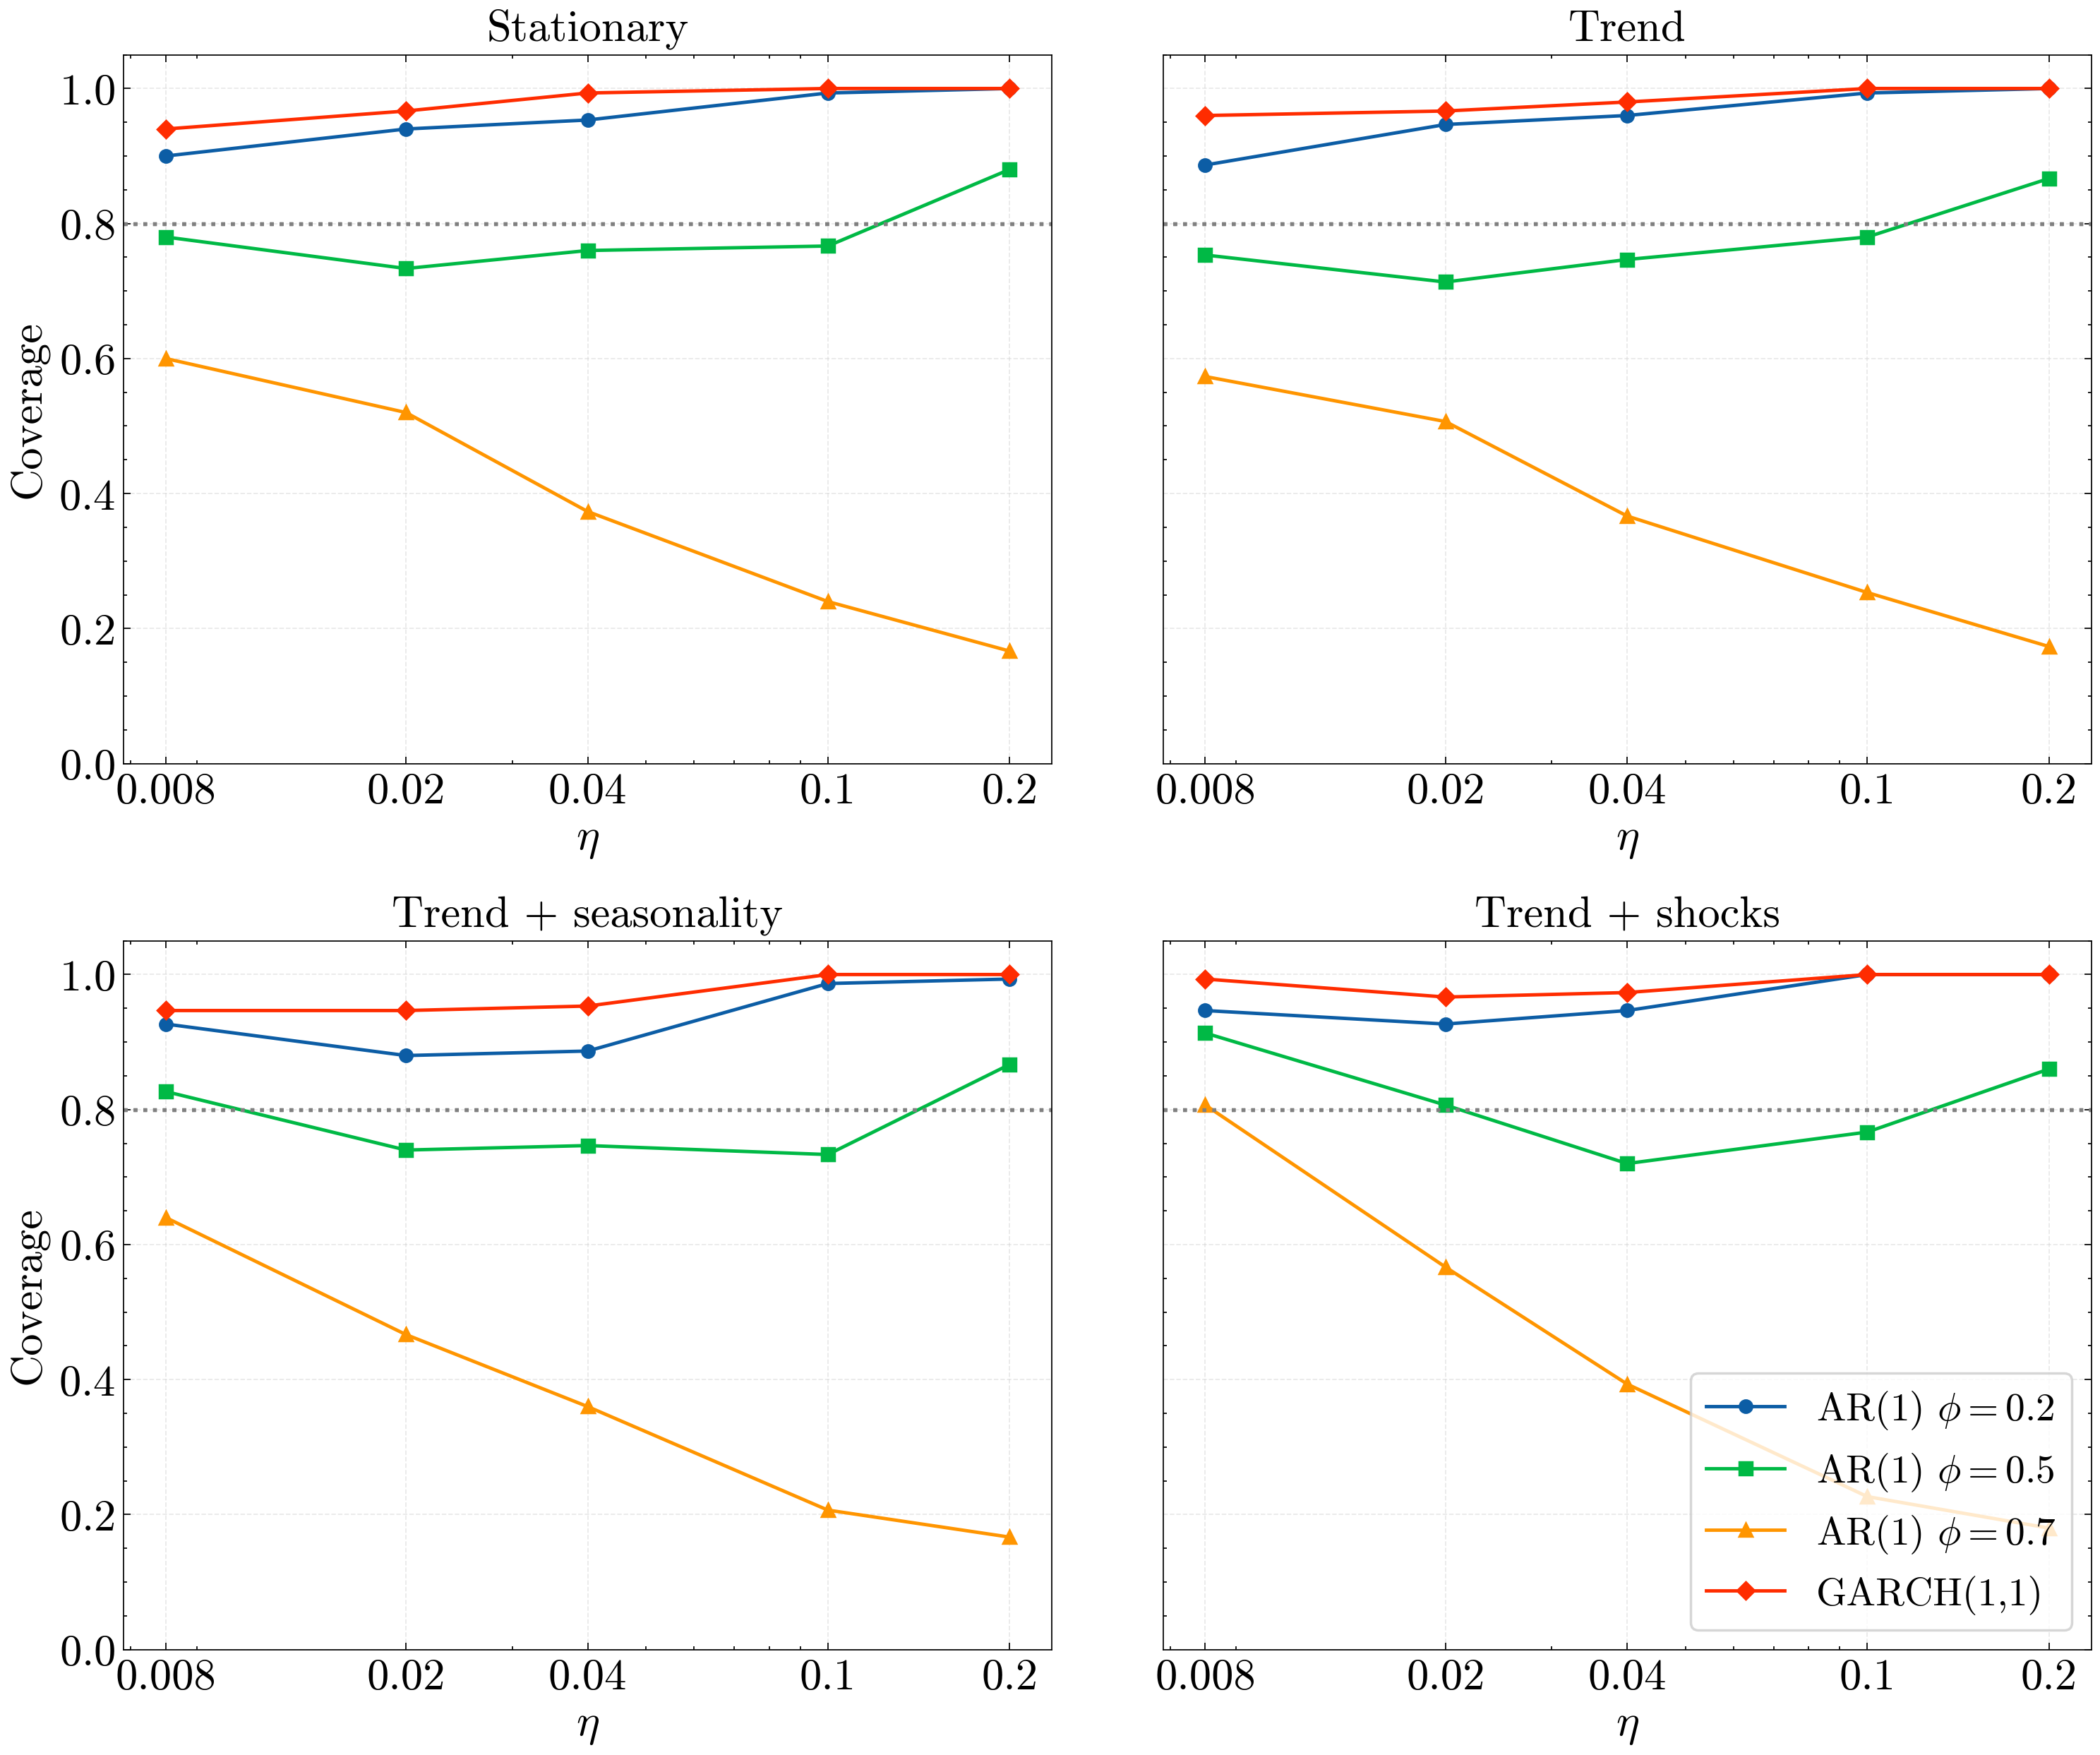

In [8]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "GARCH_base/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (trend)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (trend)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (trend)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_trend/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + seasonality": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (season)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.5$ (season)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.7$ (season)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "GARCH_season/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (shocks)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (shocks)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (shocks)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_shock/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_ewma_alpha02.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=["Stationary", "Trend", "Trend + seasonality", "Trend + shocks"],
    layout=(2, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

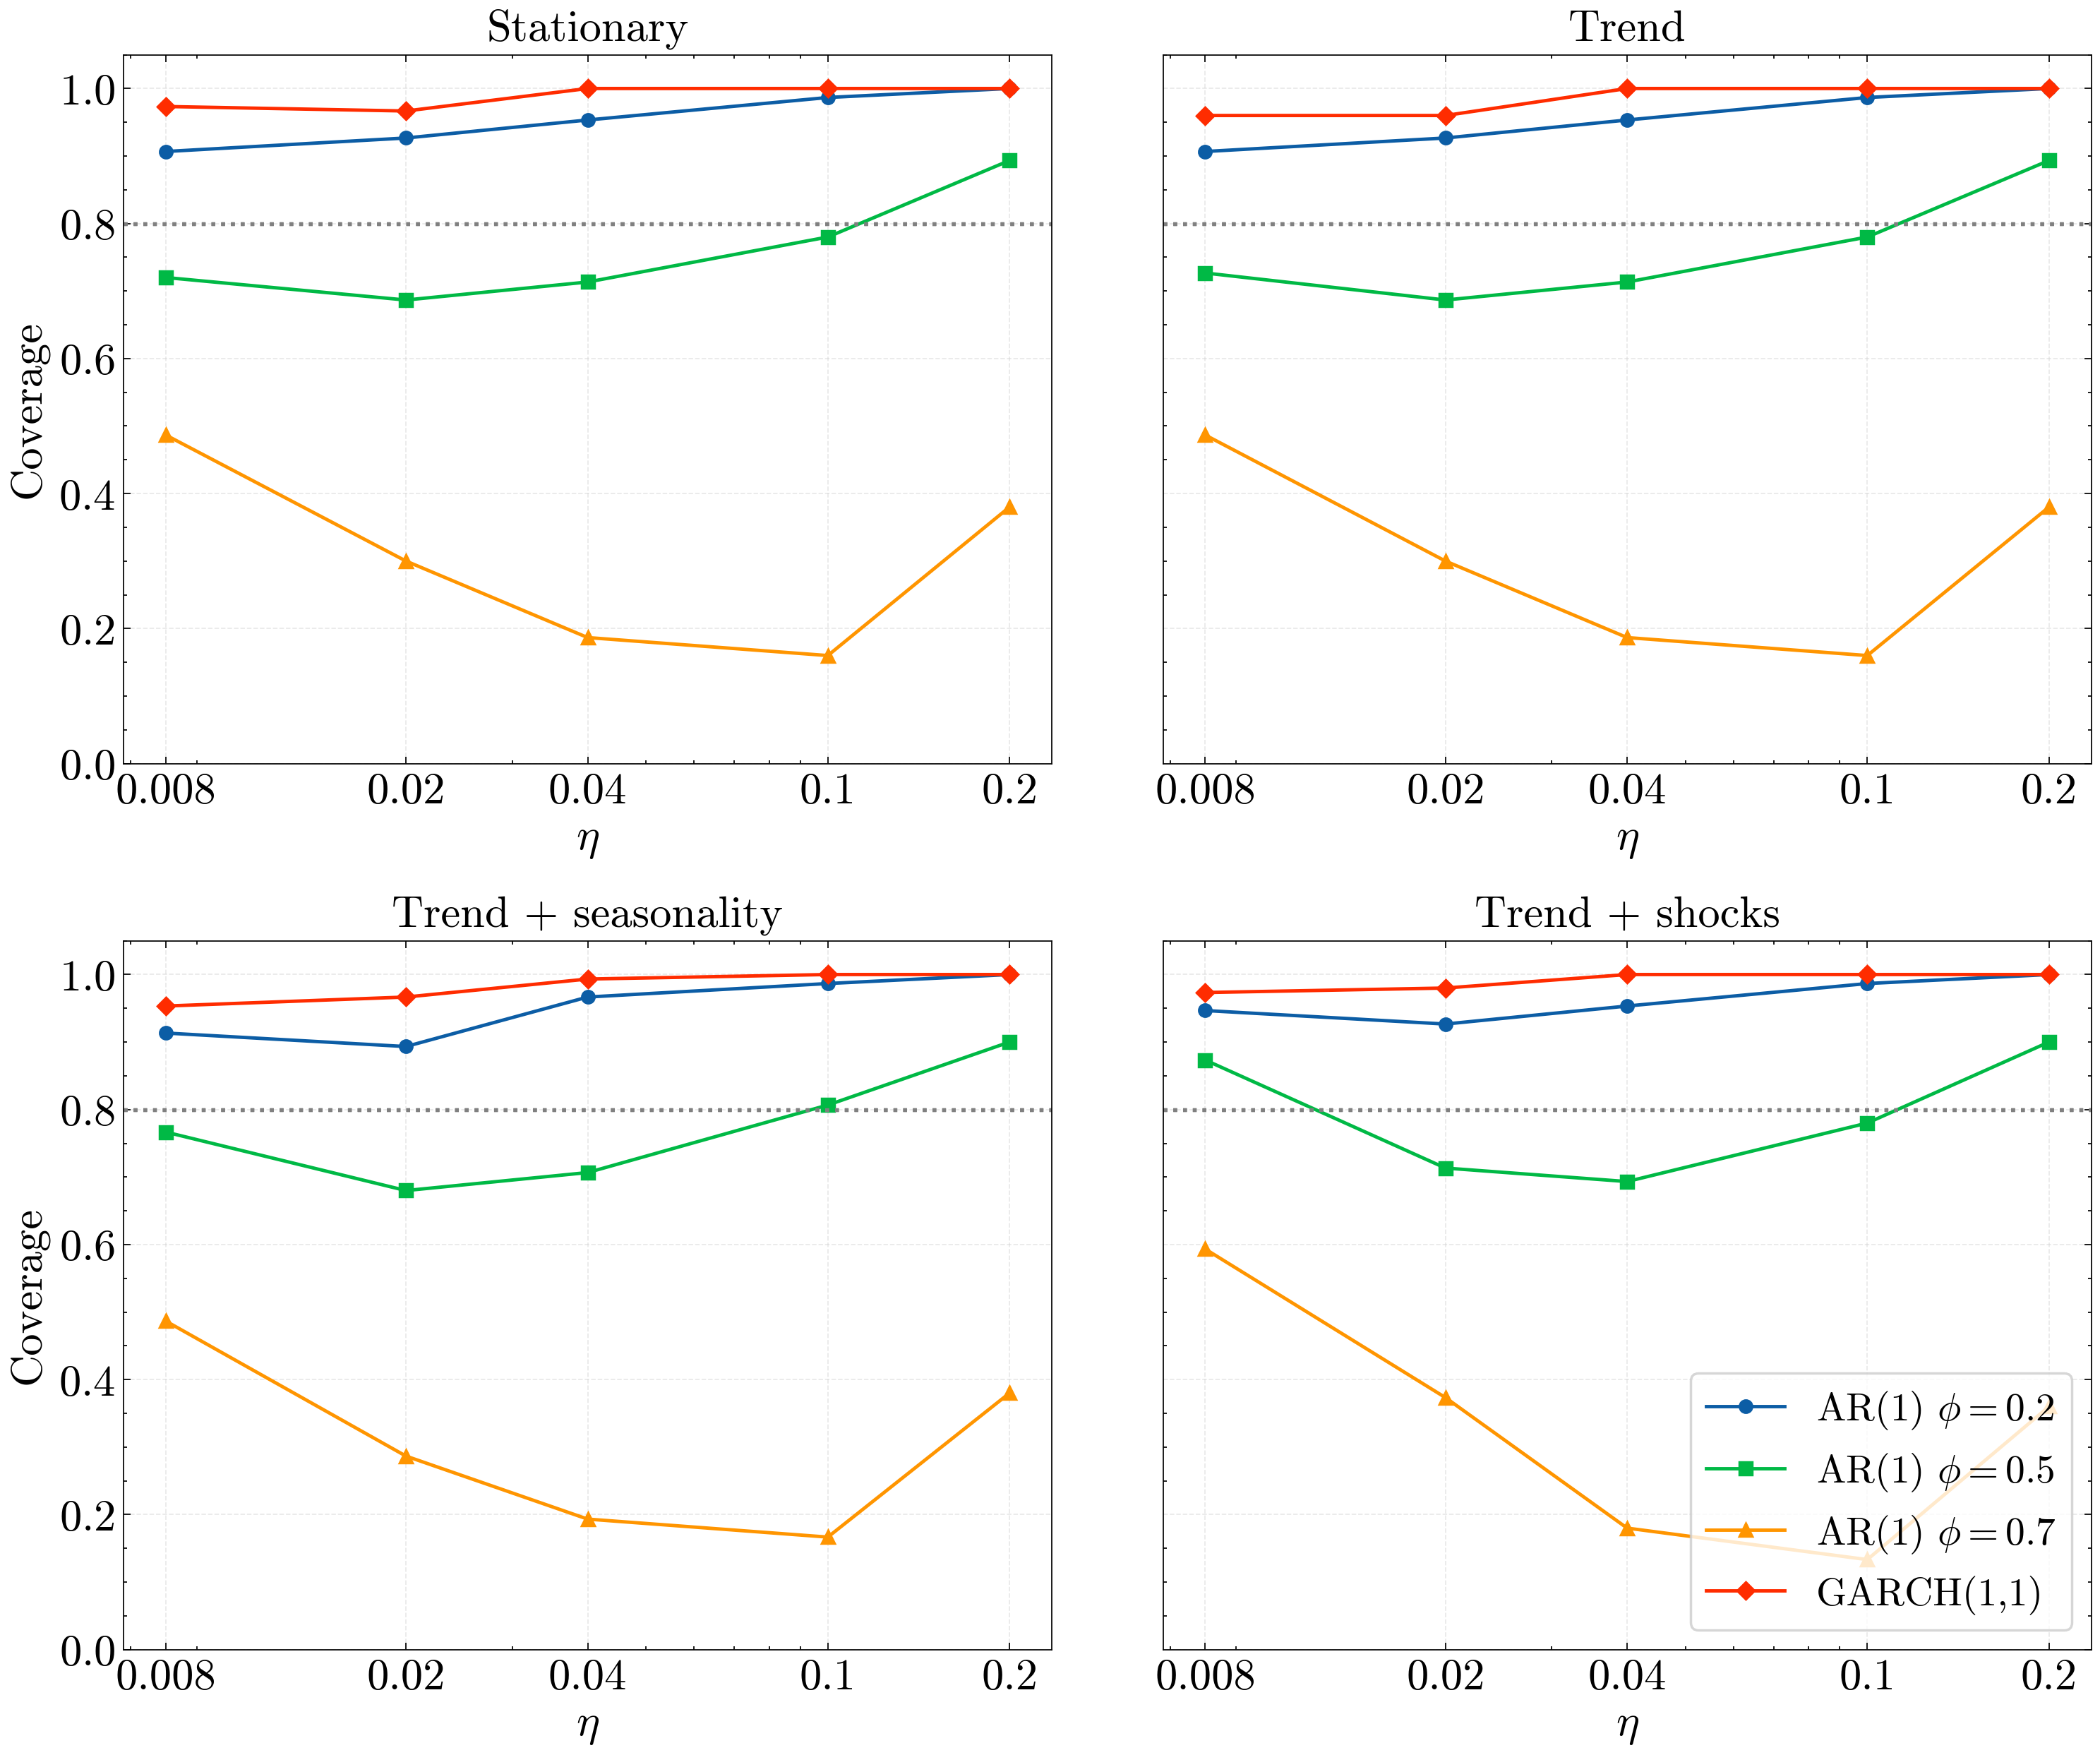

In [9]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
            base
            / "GARCH_base/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (trend)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (trend)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (trend)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_trend/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + seasonality": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (season)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.5$ (season)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.7$ (season)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "GARCH_season/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (shocks)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (shocks)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (shocks)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
            base
            / "GARCH_shock/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-permanent_p-0p005_scale-2__smooth-brown__tr-student__bi-500__vw-400__alpha-0p2__n-3500__nseries-150__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)

save_path = outdir / "sweep_overlay_grid_brown_alpha02.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=["Stationary", "Trend", "Trend + seasonality", "Trend + shocks"],
    layout=(2, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,  # <-- use the subplot legend
    legend_panel_index=-1,  # bottom-right
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
)

In [10]:
base = Path("..") / "experiments"

panels_paths = {
    "Stationary": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (base)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200.npz",
            base
            / "AR(1) $\phi=0.5$ (base)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200.npz",
            base
            / "AR(1) $\phi=0.7$ (base)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200.npz",
            base
            / "GARCH_base/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (trend)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (trend)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (trend)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "GARCH_trend/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + seasonality": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (season)/sweep_proc-AR1Process__phi-0p2__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.5$ (season)/sweep_proc-AR1Process__phi-0p5__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "AR(1) $\phi=0.7$ (season)/sweep_proc-AR1Process__phi-0p7__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
            base
            / "GARCH_season/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-none_p-0_scale-1__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001__seaA-0p4__seaP-400.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
    "Trend + shocks": {
        "paths": [
            base
            / "AR(1) $\phi=0.2$ (shocks)/sweep_proc-AR1Process__phi-0p2__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.5$ (shocks)/sweep_proc-AR1Process__phi-0p5__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "AR(1) $\phi=0.7$ (shocks)/sweep_proc-AR1Process__phi-0p7__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
            base
            / "GARCH_shock/sweep_proc-GARCH11Process__garch-{'omega':0p020000000000000018,'alpha':0p08,'beta':0p9}__shock-type-permanent_p-0p005_scale-2__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-25__B-200__trend-0p001.npz",
        ],
        "labels": [
            r"AR(1) $\phi=0.2$",
            r"AR(1) $\phi=0.5$",
            r"AR(1) $\phi=0.7$",
            r"GARCH(1,1)",
        ],
    },
}

# turn paths → sweeps (no nested class call in the plotter)
panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

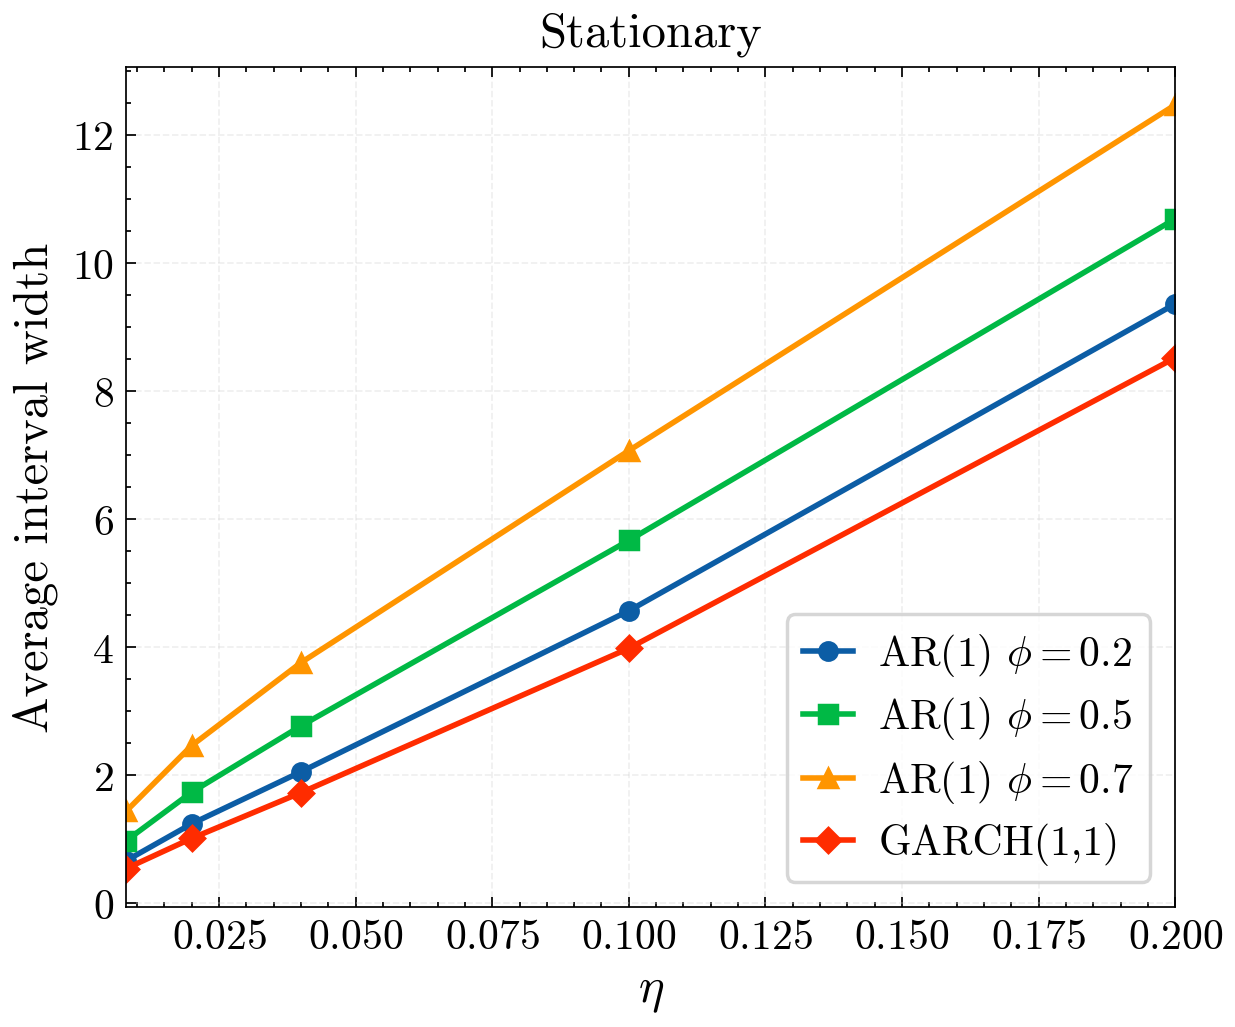

In [11]:
plotter = BootstrapPlotter(style="science", figsize=(12, 10), dpi=250)

stationary_panels = {"Stationary": panels["Stationary"]}

fig_stat, ax_stat = plotter.plot_avg_uniform_width_grid(
    stationary_panels,
    order=["Stationary"],
    layout=(1, 1),
    figsize=(5, 4),  # tune size for a single panel
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=12,
    save_path=Path("figs/avg_uniform_widths_stationary.pdf"),
    show=True,
    legend_inside_bottom_right=True,
    legend_loc="inplot-br",
    log_eta=False,
)

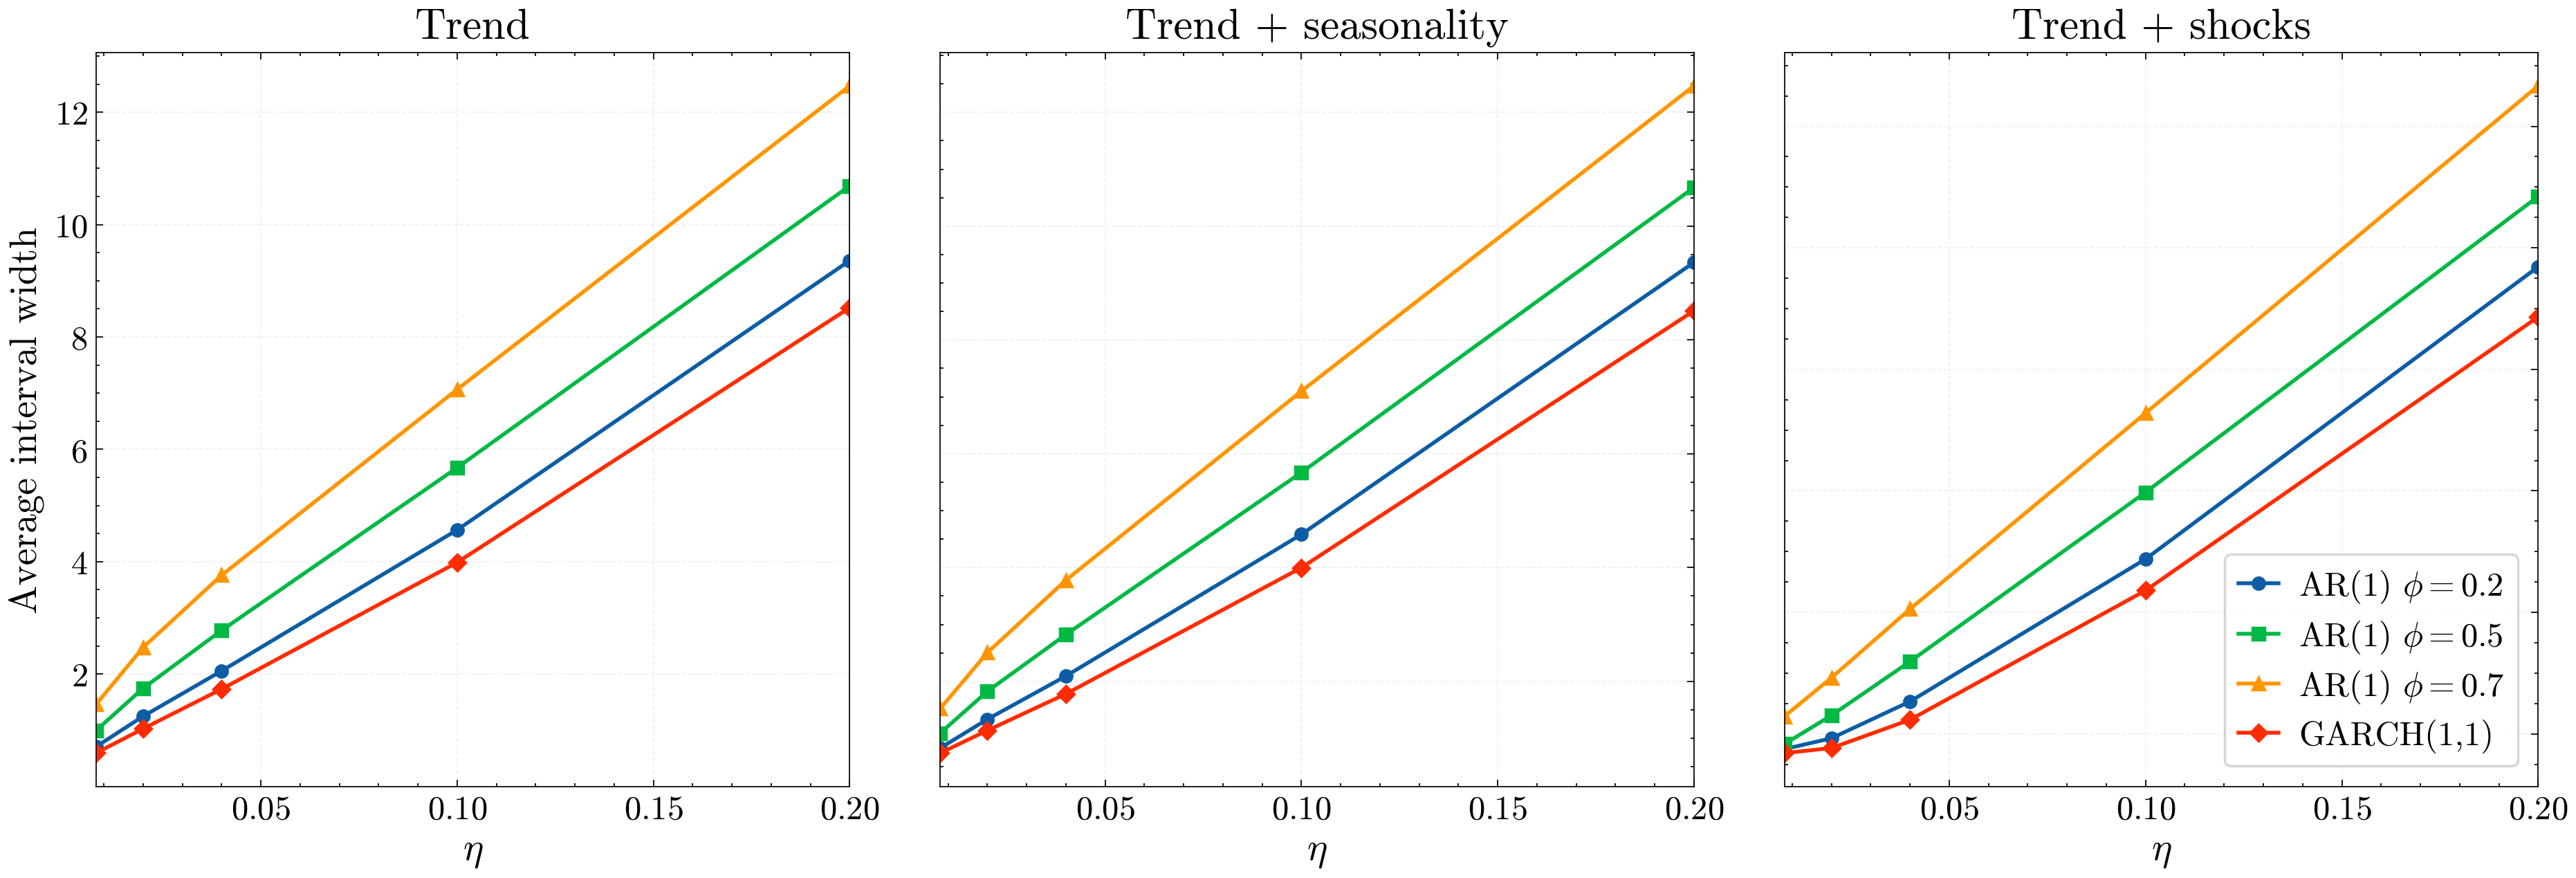

In [12]:
other_order = ["Trend", "Trend + seasonality", "Trend + shocks"]
other_panels = {k: panels[k] for k in other_order}

fig_trends, axes_trends = plotter.plot_avg_uniform_width_grid(
    other_panels,
    order=other_order,
    dpi=250,
    layout=(1, 3),
    figsize=(15, 5),  # wider figure for 3 panels
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=14,
    axis_labelsize=16,
    tick_labelsize=14,
    title_size=18,
    save_path=Path("figs/avg_uniform_widths_trends.pdf"),
    show=True,
    legend_inside_bottom_right=True,
    legend_loc="inplot-br",
    log_eta=False,
)